In [2]:
""" Import Libraries """
from sklearn.cluster            import KMeans
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import silhouette_score
from sklearn.decomposition      import PCA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import datetime as dt

<h2>EDA (Exploratory Data Analysis) and Cleaning</H2>

In [4]:
""" dataset & report """

file = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\raw\Online Retail.xlsx"
df_raw = pd.read_excel(file)

N_rows, N_cols = df_raw.shape
print(f"Number of rows: {N_rows:,} | Number of Columns: {N_cols:,}\n")
report = []
for col in df_raw.columns:
    report.append({
        "Col":      col,
        "len":      df_raw[col].count(),
        "dtype":    df_raw[col].dtypes,
        "NaN":      df_raw[col].isnull().sum(),
        "0":        df_raw[col].eq(0).sum(),
        "'0'":      df_raw[col].eq("0").sum(),
        "Unique":   df_raw[col].unique()[0:7].tolist(),
        "N_Unique": df_raw[col].nunique()
    })
df_report = pd.DataFrame(report)
pd.set_option("display.max_colwidth", None)
df_report

Number of rows: 541,909 | Number of Columns: 8



,Col,len,dtype,NaN,0,'0',Unique,N_Unique
0,InvoiceNo,541909,object,0,0,0,"[536365, 536366, 536367, 536368, 536369, 536370, 536371]",25900
1,StockCode,541909,object,0,0,0,"[85123A, 71053, 84406B, 84029G, 84029E, 22752, 21730]",4070
2,Description,540455,object,1454,0,0,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE METAL LANTERN, CREAM CUPID HEARTS COAT HANGER, KNITTED UNION FLAG HOT WATER BOTTLE, RED WOOLLY HOTTIE WHITE HEART., SET 7 BABUSHKA NESTING BOXES, GLASS STAR FROSTED T-LIGHT HOLDER]",4223
3,Quantity,541909,int64,0,0,0,"[6, 8, 2, 32, 3, 4, 24]",722
4,InvoiceDate,541909,datetime64[ns],0,0,0,"[2010-12-01 08:26:00, 2010-12-01 08:28:00, 2010-12-01 08:34:00, 2010-12-01 08:35:00, 2010-12-01 08:45:00, 2010-12-01 09:00:00, 2010-12-01 09:01:00]",23260
5,UnitPrice,541909,float64,0,2515,0,"[2.55, 3.39, 2.75, 7.65, 4.25, 1.85, 1.69]",1630
6,CustomerID,406829,float64,135080,0,0,"[17850.0, 13047.0, 12583.0, 13748.0, 15100.0, 15291.0, 14688.0]",4372
7,Country,541909,object,0,0,0,"[United Kingdom, France, Australia, Netherlands, Germany, Norway, EIRE]",38


In [5]:
""" New features to clean the dataset """

df_raw["CustomerID"] = df_raw["CustomerID"].replace(np.nan, 99999.0)
df_raw["Return"] = np.where(df_raw["Quantity"]<0, 1, 0)
df_raw["Customer_Type"] = np.where(df_raw["CustomerID"]==99999.0, "Customer_Final", "Customer_ID")
df_raw["Description_Error"] = np.where(df_raw["Description"].isnull(), 1, 0)
df_raw["Gift"] = np.where(df_raw["UnitPrice"].eq(0), 1, 0)
df_raw["Total_Invoice"] = df_raw["Quantity"] * df_raw["UnitPrice"]

In [ ]:
df_raw[df_raw["UnitPrice"].eq(0) & df_raw["Description"].isnull()].shape

(1454, 13)

In [12]:
df_raw[df_raw["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Return,Customer_Type,Description_Error,Gift,Total_Invoice
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,99999.0,United Kingdom,0,Customer_Final,0,0,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,99999.0,United Kingdom,0,Customer_Final,0,0,-11062.06


In [13]:
""" Copy and Clean """

df_clean = df_raw.copy()
df_clean = df_clean.drop(df_clean[df_clean["Customer_Type"].eq("Customer_Final")].index)
df_clean = df_clean.drop(df_clean[df_clean["Return"].eq(1)].index)
df_clean = df_clean.drop(df_clean[df_clean["Gift"].eq(1)].index)
df_clean = df_clean.drop(columns=["Return", "Customer_Type", "Description_Error", "Gift"])

In [14]:
""" Outliers """
df_clean[["Quantity", "UnitPrice", "Total_Invoice"]].describe(include="all")

,Quantity,UnitPrice,Total_Invoice
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [16]:
q_limit = df_clean["Quantity"].quantile(0.999)
m_limit = df_clean["Total_Invoice"].quantile(0.999)

df_final = df_clean[(df_clean["Quantity"]<=q_limit) & (df_clean["Total_Invoice"]<=m_limit)]

print(f"N_rows of df_raw:   {len(df_raw):,}")
print(f"N_rows of df_clean: {len(df_clean):,}")
print(f"N_rows of df_final: {len(df_final):,}")
print(f"Total drop rows:    {len(df_raw) - len(df_final):,}")

N_rows of df_raw:   541,909
N_rows of df_clean: 397,884
N_rows of df_final: 397,236
Total drop rows:    144,673


<h2>Feature Engineering: RFM Metrics (Recency, Frequency and Monetary)</h2>

In [18]:
""" RFM columns """
snapshot_date = df_final["InvoiceDate"].max() + dt.timedelta(days=1)
rfm = df_final.groupby("CustomerID").agg({
    "InvoiceDate":      lambda x: (snapshot_date - x.max()).days,   # Recency: days without buying
    "InvoiceNo":        "nunique",  # Frequency: Number of unique transactions
    "Total_Invoice":    "sum"   # Monetary: Total money spend
}).reset_index()

rfm.rename(columns={
    "InvoiceDate":      "Recency",
    "InvoiceNo":        "Frequency",
    "Total_Invoice":    "Monetary"
}, inplace=True)

""" RFM Scores and Output """
rfm["R_scores"] = pd.qcut(x=rfm["Recency"], q=4, labels=[4,3,2,1])
rfm["F_scores"] = pd.qcut(x=rfm["Frequency"].rank(method="first"), q=4, labels=[1,2,3,4])
rfm["M_scores"] = pd.qcut(x=rfm["Monetary"], q=4, labels=[1,2,3,4])

rfm["RFM_score"] = (rfm["R_scores"].astype(str) + rfm["F_scores"].astype(str) + rfm["M_scores"].astype(str))
rfm["RFM_Output"] = rfm[["R_scores", "F_scores", "M_scores"]].astype(int).sum(axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_scores,F_scores,M_scores,RFM_score,RFM_Output
0,12347.0,2,7,4310.00,4,4,4,444,12
1,12348.0,75,4,1797.24,2,3,4,234,9
2,12349.0,19,1,1757.55,3,1,4,314,8
3,12350.0,310,1,334.40,1,1,2,112,4
4,12352.0,36,8,2506.04,3,4,4,344,11


<h2>Logarithmic Transformation and Scaler to RFM</h2>

In [19]:
rfm.head(2)

,CustomerID,Recency,Frequency,Monetary,R_scores,F_scores,M_scores,RFM_score,RFM_Output
0,12347.0,2,7,4310.00,4,4,4,444,12
1,12348.0,75,4,1797.24,2,3,4,234,9


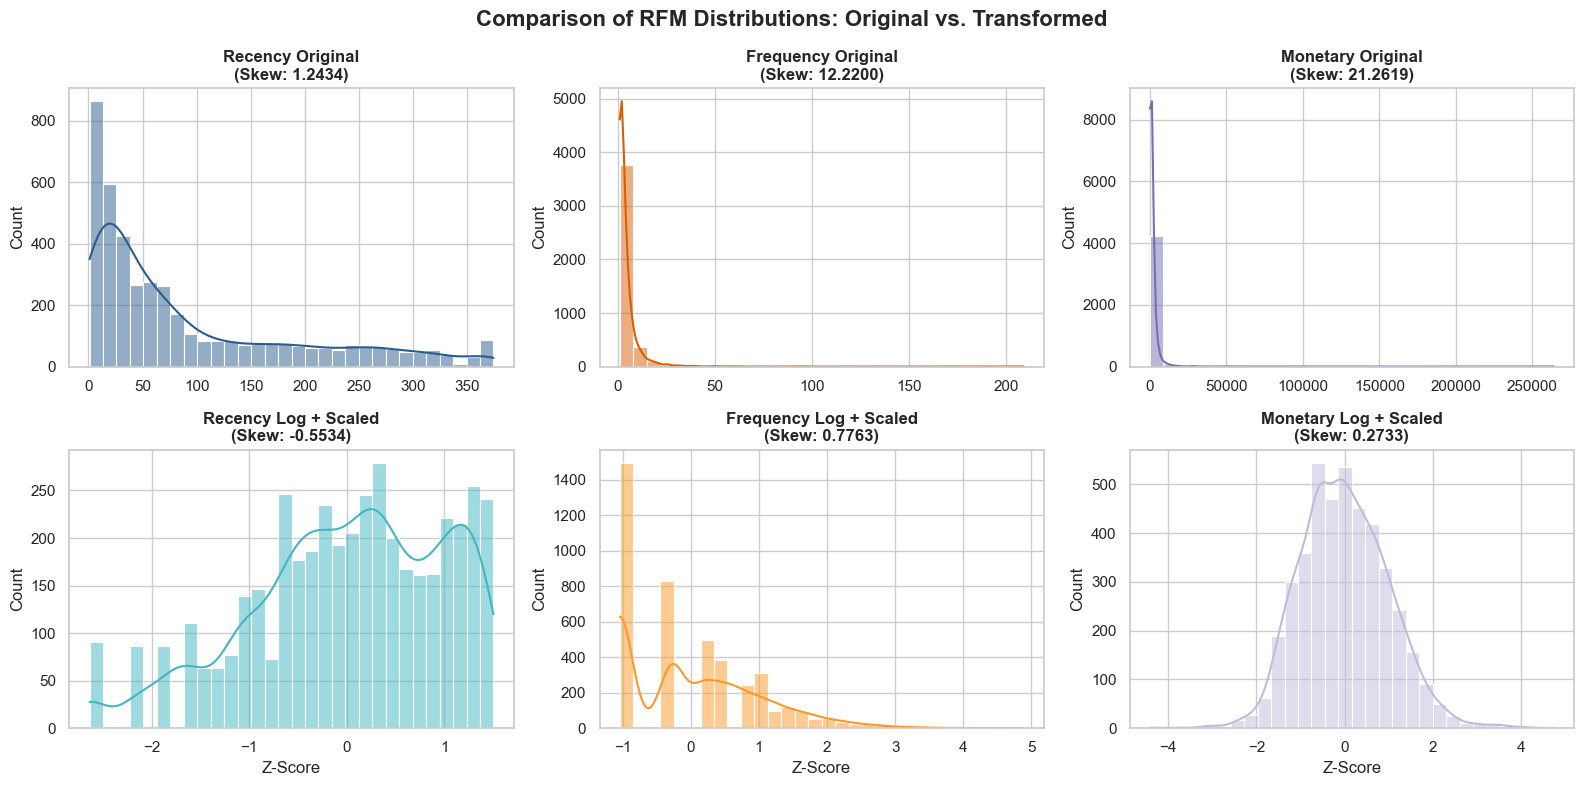

In [23]:
""" Style of the graph """
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

""" Logarithmic transformation """
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log)

""" Scaler """
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_log), columns=["Recency", "Frequency", "Monetary"])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,8))
features = ["Recency", "Frequency", "Monetary"]
colors_without = ["#2b5c8f", "#d95f02", "#7570b3"]
colors_with = ["#41b6c4", "#fe9929", "#bcbddc"]

""" Distribution graphic without log and scaler """
for i, col in enumerate(features):
    sns.histplot(data=rfm[col], kde=True, ax=axes[0,i], color=colors_without[i], bins=30)
    skewness = rfm[col].skew()
    axes[0,i].set_title(f"{col} Original\n(Skew: {skewness:,.4f})", fontsize=12, fontweight="bold")
    axes[0,i].set_xlabel("")

""" Distribution graphic with log and scaler """
for i, col in enumerate(features):
    sns.histplot(data=rfm_scaled[col], kde=True, ax=axes[1,i], color=colors_with[i], bins=30)
    skewness_scaled = rfm_scaled[col].skew()
    axes[1,i].set_title(f"{col} Log + Scaled\n(Skew: {skewness_scaled:,.4f})", fontsize=12, fontweight="bold")
    axes[1,i].set_xlabel("Z-Score")

plt.suptitle("Comparison of RFM Distributions: Original vs. Transformed", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
rfm_scaled["CustomerID"] = rfm["CustomerID"]
rfm_scaled.head()

,Recency,Frequency,Monetary,CustomerID
0,-2.151398,1.114705,1.443921,12347.0
1,0.382784,0.493068,0.742149,12348.0
2,-0.577269,-1.046865,0.724232,12349.0
3,1.375024,-1.046865,-0.607078,12350.0
4,-0.130416,1.263035,1.008879,12352.0


<h2>Cluster Profile</h2>